In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def trapezio(a, b, h, N):
    iab = (h/2)*(func(a) + func(b) + 2*somat(a, h, N))
    return iab

def somat(a, h, N):
    soma = 0
    for k in range(1, N):
        soma += sino(a + k*h)
    return soma

### Problem 1

Considere a integral

$$E(x) = \int_{0}^{x}e^{-t^{2}}dt.$$

a) Escreva um programa para calcular $E(x)$ para valores de $x$ entre $0$ e $3$, usando um passo
de $0.1$. Escolha o método de sua preferência para calcular a integral e use um número apropriado de fatias.

In [1]:
def expon(t):
    return np.exp(-(t**2))

In [6]:
xs = np.arange(0, 3, 0.1)

a, b, N = 0, 3, 1000
h = (b-a)/N

fa, fb = expon(a), expon(b)

s = (h*fa)/2 + (h*fb)/2
soma = 0

for k in range(1, N):
    soma += expon(a + k*h)

s += h*soma
s

np.float64(0.8862073477041791)

b) Quando você estiver convencido de que seu programa está funcionando , extenda ele para que faça um gráfico de $E(x)$ em função de $x$.

In [8]:
Es = []
a, N = 0, 1000

for x in xs:
    h = (x-a)/N
    fa, fb = expon(a), expon(x)

    E = (h*fa)/2 + (h*fb)/2
    
    for k in range(0, N):
        E += (h/2)*expon(a + k*h)
    Es.append(E)

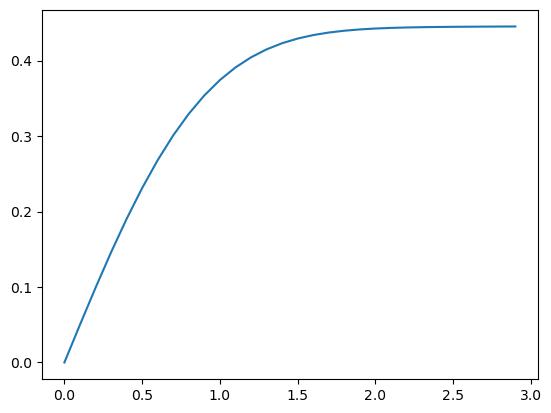

In [9]:
plt.plot(xs, Es)

Note que não há nenhum método para realizar esta integral analiticamente, então abordagens
numéricas são o único modo possível.

### Problem 2  O limite da difracão em um telescópio

Nossa habilidade para ver detalhes em observações astronômicas é limitada pela difração da luz nos telescópios. As luzes vindo das estrelas podem ser tratadas efetivamente como vindas de uma fonte pontual no infinito. Quando a luz, com comprimento de onda $\lambda$, passa através da abertura circular de um telescópio (que consideraremos tendo raio unitário) e é focalizada no plano focal, produz não um ponto e sim um padrão de difração circular consistindo de um ponto central cercado por uma série de anéis concêntricos. A intensidade da luz nesse padrão de difração é dada por

$$ I(r) = \left( \frac{J_{1}(kr)}{kr} \right)^{2}, $$

onde $r$ é a distância no plano focal do centro do padrão de difração, $k = 2\pi/\lambda$, e $J_1(x)$ é a função de Bessel. As funções de Bessel $J_m(x)$ são dadas por

$$ J_{m}(x) = \frac{1}{\pi} \int_{0}^{\pi} \cos(m\theta - x\sin\theta) d\theta, $$

onde m é um inteiro não negativo e $x ≥ 0$.

a) Escreva uma função $J(m,x)$ que calcula o valor de $J_{m}(x)$ usando a regra de Simpson com $N = 1000$ pontos. Utilize sua função para fazer um gráfico das funções de Bessel $J_{0}$, $J1_{1}$ e $J_{2}$ em função de $x$, de $x = 0$ até $x = 20$. Coloque todas as curvas em um mesmo gráfico.

In [16]:
import numpy as np

x = np.linspace(0, 20, 100)
ms = np.arange(0, 5, 1)

N = 1000
a, b = 0, np.pi
h = (b-a)/N

def func(theta, m, x_value):
    return np.cos(m*theta - x_value*np.sin(theta))

def simpson(a, b, h, m, x_value):
    soma = 0
    for k in range(1, N):
        if k%2 != 0:
            soma += 4*func(a + k*h, m, x_value)
        else:
            soma += 2*func(a + k*h, m, x_value)
    return (h/3)*(func(a, m, x_value) + func(b, m, x_value) + soma)

Js_x = []
for m in ms:
    Js_linha = []
    for x_value in x:
        Js_linha.append((1/np.pi)*simpson(a, b, h, m, x_value))
    Js_x.append(Js_linha)

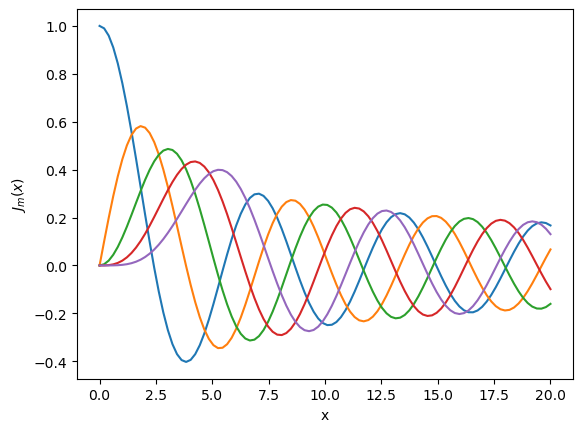

In [17]:
plt.xlabel('x')
plt.ylabel('$J_{m}(x)$')

for m in ms:
    plt.plot(x, Js_x[m])
plt.show()

b) Escreva um segundo programa que faça um gráfico de densidade (no pylab você pode usar a função imshow) do padrão de difração circular de uma fonte de luz com $\lambda = 500\text{nm}$, em uma região quadrada no plano focal usando as fórmulas acima. Sua figura deve cobrir os valores $r$ de $0$ até $1\mu\text{m}$

In [14]:
lanbda = 500*1e-9
k = (2*np.pi)/lanbda

xs = np.linspace(-1e-6, 1e-6, 100)
ys = np.linspace(-1e-6, 1e-6, 100)

matrix = []

for i in range(0, 100):
    line = []
    for j in range(0, 100):

        r = np.sqrt(xs[i]**2 + ys[i]**2)
        arg = k*r
        jkr = bessel(1, arg)

        line.append((jkr/arg)**2)
    matrix.append(line)

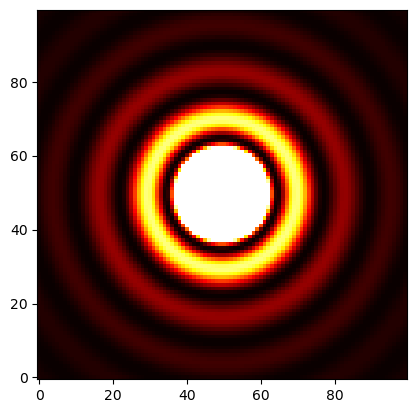

In [19]:
import matplotlib.pyplot as plt
from numpy import loadtxt

plt.imshow(I_matriz, origin = 'lower', vmax = 0.005)
plt.hot()

Dica 1: Pode ser útil saber que $\lim_{x \to 0} J_1(x)/x = 1/2$.

Dica 2: O ponto central no padrão de difração é tão brilhante que pode ser difícil ver os anéis em torno dele na tela do computador. Se você tiver problemas com isso, uma maneira simples de resolver o problema é usar um gráfico de densidade com cores. O esquema “hot” funciona bem. Para uma solução mais sofisticada do problema, a função imshow tem um argumento adicional vmax que permite você especificar o valor que corresponde ao ponto mais brilhante no gráfico. Por exemplo, se você fizer “imshow(x, vmax=0.1)”, então elementos em x com valores maiores ou iguais a 0.1 irão produzir a cor mais brilhante na tela. Diminuindo o valor vmax, você pode reduzir a faixa total de valores entre os brilhos mínimos e máximos e então aumentar a sensitividade no gráfico tornando os detalhes mais visíveis. Existe também um argumento vmin que pode ser usado para definir o valor que corresponde à cor menos brilhante. Para esse exercício o valor vmax=0.01 parece funcionar bem.

### Problem 3 

Escreva um programa, ou modifique um anterior, para mais uma vez calcular o valor da integral $\int_{0}^{2} (x^4 - 2x + 1) dx$, usando a regra do trapézio com 20 fatias. Porém, dessa vez faça o programa imprimir uma estimativa do erro do resultado, calculado usando o método “prático” discutido em aula. Para fazer isto, você precisa avaliar a integral duas vezes, uma vez com $N_1 = 10$ fatias e depois novamente com $N_2 = 20$ fatias. Então a equação

$$  e_{2} = \frac{1}{3}(I_{2}-I_{1})), $$

te dá o erro. Como o erro calculado deste modo se compara com o erro calculado através da diferença entre o valor numérico e o valor correto 4.4? Por que os dois não concordam perfeitamente?

In [101]:
def polin(x):
    return x**4 - 2*x + 1

In [102]:
def trap3(a, b, h, N):
    soma = (h/2)*polin(a) + (h/2)*polin(b)
    for k in range(1, N):
        soma += h*polin(a + k*h)
    return soma

In [103]:
a, b, N, N2 = 0.0, 2.0, 20, 40
h, h2 = (b-a)/N, (b-a)/N2

I = trap3(a, b, h, N)
I2 = trap3(a, b, h2, N2)

e2 = (1/3)*(I2 - I1)

err_diff = I2 - 4.4

In [104]:
print(f'pratical error: {abs(e2)}')
print(f'diff error: {abs(err_diff)}')

pratical error: 0.03329791666666626
diff error: 0.006666250000001206


Os erros são diferentes porque o erro prático desconsidera termos após a segunda ordem dominante $\mathcal{O}(h^{2})$. Por outro lado, a diferença entre a aproximação do trapézio e o valor real $4.4$ se dá pela série completa de Euler-Maclaurin **(equação 5.16 do Newmann)**, onde esta considera todos os termos, incluindo os de ordem superior à $\mathcal{O}(h^{2})$.

### Problem 4 Considere a integral

$$  I = \int_{0}^{1} \sin^{2}(\sqrt{100x})dx. $$

Escreva um programa que usa o método da regra do trapézio adaptativa da seção 5.3 e Eq. (5.34) para calcular o valor desta integral até uma precisão aproximada de $\epsilon = 10^{-6}$ (ou seja, correto até seis dígitos após o ponto decimal). Comece com uma única fatia de integração e aumente $N$ depois para dois, quatro, oito e assim por diante. Faça seu programa escrever o número de fatias, a sua estimativa da integral e a sua estimativa do erro da integral, para cada valor do número de fatias $n$, até que a precisão alvo seja atingida. (Dica: Você deve encontrar que o resultado está em torno de $I = 0,45$.)

In [105]:
def sino(x):
    v = np.sin(np.sqrt(100*x))**2
    return v

In [106]:
def trap4(a, b, h, N):
    soma = (h/2)*sino(a) + (h/2)*sino(b)
    for k in range(1, N):
        soma += h*sino(a + k*h)
    return soma

In [100]:
a, b = 0, 1
N = 1
h = (b-a)/N

stop = 1e-6

h = (b-a)/N
h2 = (b-a)/(2*N)

I1 = trapezio(a, b, h, N)
I2 = trapezio(a, b, h2, 2*N)

e_atual = (1/3)*(I2 - I1)

NameError: name 'trapezio' is not defined

In [20]:
print(f'numero de fatias N: {N}')
print(f'estimativa da integral I1: {I1}')
print(f'estimativa do erro da integral e_atual: {e_atual}')

numero de fatias N: 1
estimativa da integral I1: 0.147979484546652
estimativa do erro da integral e_atual: 0.05908414108660753


In [21]:
while(abs(e_atual) > stop):
    N *= 2
    h, h2 = (b-a)/N, (b-a)/(2*N)
    
    I1 = trapezio(a, b, h, N)
    I2 = trapezio(a, b, h2, 2*N)
    e_atual = (1/2)*(I2-I1)

print(f'numero de fatias N: {N}')
print(f'estimativa da integral I1: {I1}')
print(f'estimativa do erro da integral e_atual: {e_atual}')

numero de fatias N: 2048
estimativa da integral I1: 0.4558306362016465
estimativa do erro da integral e_atual: 7.11038312034562e-07


In [3]:
a = np.pow(2, 3)

In [4]:
a

np.int64(8)